In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import imageio.v2 as imageio

import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import concatenate

Matplotlib is building the font cache; this may take a moment.


In [4]:
project_path = os.path.join(os.getcwd(), 'data')
image_path = os.path.join(project_path, 'leftImg8bit_trainvaltest', 'leftImg8bit', 'train')
mask_path = os.path.join(project_path, 'gtFine', 'train')

In [5]:

print("Current working directory:", os.getcwd())
print("Image path:", image_path)
print("Mask path:", mask_path)
print("Image path exists:", os.path.exists(image_path))
print("Mask path exists:", os.path.exists(mask_path))

Current working directory: /Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation
Image path: /Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train
Mask path: /Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/gtFine/train
Image path exists: True
Mask path exists: True


In [6]:
image_list = []
mask_list = []

In [7]:
# Iterate through city subdirectories
for city in os.listdir(image_path):
    city_image_path = os.path.join(image_path, city)
    city_mask_path = os.path.join(mask_path, city)
    
    if os.path.isdir(city_image_path) and not city.startswith('.'):
        image_list.extend([os.path.join(city_image_path, img) for img in os.listdir(city_image_path) if img.endswith('_leftImg8bit.png')])
        mask_list.extend([os.path.join(city_mask_path, msk) for msk in os.listdir(city_mask_path) if msk.endswith('_gtFine_labelIds.png')])

In [8]:
image_list.sort()
mask_list.sort()

In [ ]:
image_list = image_list[:1500]
mask_list = mask_list[:1500]

print("Number of images:", len(image_list))
print("Number of masks:", len(mask_list))
print("First image:", image_list[0])
print("First mask:", mask_list[0])

Number of images: 300
Number of masks: 300
First image: /Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000000_000019_leftImg8bit.png
First mask: /Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/gtFine/train/aachen/aachen_000000_000019_gtFine_labelIds.png


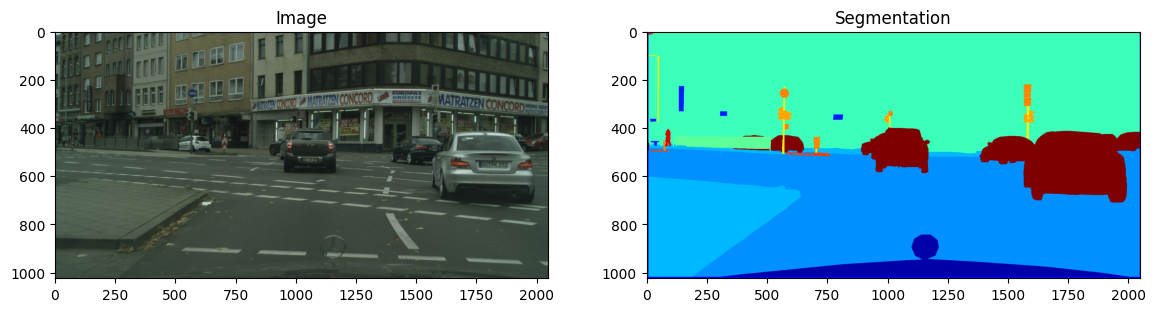

In [10]:
N = 3
img = imageio.imread(image_list[N])
mask = imageio.imread(mask_list[N])
#mask = np.array([max(mask[i, j]) for i in range(mask.shape[0]) for j in range(mask.shape[1])]).reshape(img.shape[0], img.shape[1])

fig, arr = plt.subplots(1, 2, figsize=(14, 10))
arr[0].imshow(img)
arr[0].set_title('Image')
arr[1].imshow(mask, cmap='jet')
arr[1].set_title('Segmentation')
plt.show()

In [11]:
image_list_ds = tf.data.Dataset.list_files(image_list, shuffle=False)
mask_list_ds = tf.data.Dataset.list_files(mask_list, shuffle=False)

for path in zip(image_list_ds.take(3), mask_list_ds.take(3)):
    print(path)

(<tf.Tensor: shape=(), dtype=string, numpy=b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000000_000019_leftImg8bit.png'>, <tf.Tensor: shape=(), dtype=string, numpy=b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/gtFine/train/aachen/aachen_000000_000019_gtFine_labelIds.png'>)
(<tf.Tensor: shape=(), dtype=string, numpy=b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000001_000019_leftImg8bit.png'>, <tf.Tensor: shape=(), dtype=string, numpy=b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/gtFine/train/aachen/aachen_000001_000019_gtFine_labelIds.png'>)
(<tf.Tensor: shape=(), dtype=string, numpy=b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000002_000019_leftImg8bit.png'>, <tf.

In [12]:
image_filenames = tf.constant(image_list)
masks_filenames = tf.constant(mask_list)

dataset = tf.data.Dataset.from_tensor_slices((image_filenames, masks_filenames))

for image, mask in dataset.take(1):
    print(image)
    print(mask)

tf.Tensor(b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000000_000019_leftImg8bit.png', shape=(), dtype=string)
tf.Tensor(b'/Users/as/Documents/Github/Data-Science/projects/14_unet_segmentation/data/gtFine/train/aachen/aachen_000000_000019_gtFine_labelIds.png', shape=(), dtype=string)


In [ ]:
def process_path(image_path, mask_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    return img, mask

In [ ]:
def preprocess(image, mask):
    input_image = tf.image.resize(image, (96, 128), method='nearest')
    input_mask = tf.image.resize(mask, (96, 128), method='nearest')
    return input_image, input_mask

In [15]:
image_ds = dataset.map(process_path)
processed_image_ds = image_ds.map(preprocess)

In [16]:
def conv_block(inputs = None, n_filters = 32, dropout_prob = 0, max_pooling = True):
    conv = Conv2D(n_filters, 3, activation='relu', padding= 'same', kernel_initializer= 'he_normal') (inputs)
    conv = Conv2D(n_filters, 3, activation='relu', padding= 'same', kernel_initializer= 'he_normal') (conv)
    
    if dropout_prob > 0:
        conv = Dropout(dropout_prob)(conv)
    
    if max_pooling:
        next_layer = MaxPooling2D(2, strides=2)(conv)
    else:
        next_layer = conv
    
    skip_connection = conv

    return next_layer, skip_connection


In [17]:
def upsampling_block(expansive_output, contractive_output, n_filters = 32):
    up = Conv2DTranspose(n_filters, 3, strides=2, padding='same') (expansive_output)
    merge = concatenate([up, contractive_output], axis=3)

    conv = Conv2D(n_filters, 3, activation= 'relu', padding= 'same', kernel_initializer= 'he_normal')(merge)
    conv = Conv2D(n_filters, 3, activation= 'relu', padding= 'same', kernel_initializer= 'he_normal')(conv)

    return conv


In [18]:
def unet_model(input_size = (96, 128, 3), n_filters = 32, n_classes = 34):

    inputs = Input(input_size)

    cblock1 = conv_block(inputs= inputs, n_filters= n_filters*1)
    cblock2 = conv_block(inputs= cblock1[0], n_filters= n_filters*2)
    cblock3 = conv_block(inputs= cblock2[0], n_filters= n_filters*4)
    cblock4 = conv_block(inputs= cblock3[0], n_filters= n_filters*8, dropout_prob=0.3)
    cblock5 = conv_block(inputs= cblock4[0], n_filters= n_filters*16, dropout_prob=0.3, max_pooling=False)

    ublock6 = upsampling_block(cblock5[0], cblock4[1], n_filters= n_filters*8)
    ublock7 = upsampling_block(ublock6, cblock3[1], n_filters= n_filters*4)
    ublock8 = upsampling_block(ublock7, cblock2[1], n_filters= n_filters*2)
    ublock9 = upsampling_block(ublock8, cblock1[1], n_filters= n_filters*1)

    conv9 = Conv2D(n_filters, 3, activation= 'relu', padding= 'same', kernel_initializer= 'he_normal')(ublock9)
    conv10 = Conv2D(n_classes, 1, padding='same')(conv9)

    model = tf.keras.Model(inputs = inputs, outputs = conv10)

    return model



In [19]:
# set model dimensions

img_height = 96
img_width = 128
num_channels = 3

unet = unet_model((img_height, img_width, num_channels))

In [20]:
unet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 128,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 128,   │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 96, 128,   │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 48, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 48, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 24, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 24, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 24, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 12, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 12, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 12, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 12, 16,    │          0 │ conv2d_7[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 6, 8, 256) │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 6, 8, 512) │  1,180,160 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 6, 8, 512) │  2,359,808 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 6, 8, 512) │          0 │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 12, 16,    │  1,179,904 │ dropout_1[0][0] 

 Total params: 8,640,834 (32.96 MB)

 Trainable params: 8,640,834 (32.96 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
	
unet.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [22]:
def display(display_list):
    plt.figure(figsize=(15, 15))

    title = ['Input Image', 'True Mask', 'Predicted Mask']

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
        plt.axis('off')
    plt.show()

(1024, 2048, 1)


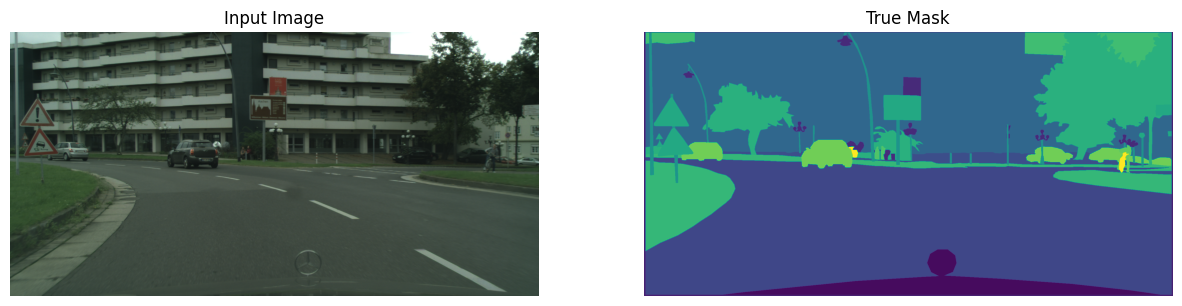

In [37]:
for image, mask in image_ds.take(1):
    sample_image, sample_mask = image, mask
    print(mask.shape)
display([sample_image, sample_mask])

(96, 128, 1)


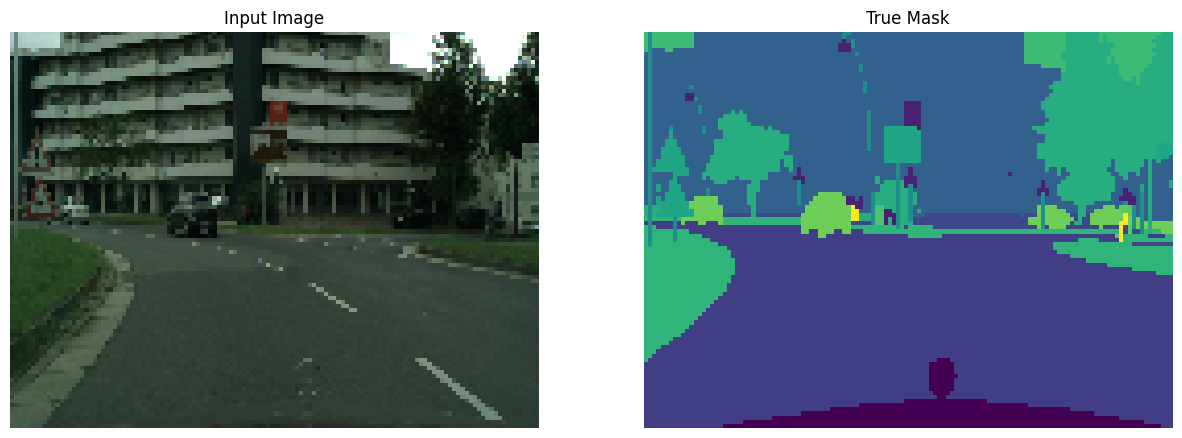

In [23]:
for image, mask in processed_image_ds.take(1):
    sample_image, sample_mask = image, mask
    print(mask.shape)
display([sample_image, sample_mask])

In [ ]:
#Train the model
EPOCHS = 15    #should at least be 40
VAL_SUBSPLITS = 5
BUFFER_SIZE = 500
BATCH_SIZE = 16   #32
processed_image_ds.batch(BATCH_SIZE)
train_dataset = processed_image_ds.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
print(processed_image_ds.element_spec)
model_history = unet.fit(train_dataset, epochs=EPOCHS)

(TensorSpec(shape=(96, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(96, 128, 1), dtype=tf.uint8, name=None))
Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 163ms/step - accuracy: 0.5602 - loss: 1.3810
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 163ms/step - accuracy: 0.5615 - loss: 1.3402
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.5588 - loss: 1.3022
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.5698 - loss: 1.2670
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - accuracy: 0.5906 - loss: 1.2169
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step - accuracy: 0.6048 - loss: 1.2015
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 174ms/step - accuracy: 0.6184 - loss: 1.1735
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 175ms/step - accuracy: 0.6264 - loss: 1.1518
Epoch 9/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 175ms/step - accuracy: 0.6335 - loss: 1.1452
Epoch 10/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 176ms/step - accuracy: 0.6417 - loss: 1.1157


In [26]:
def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[0]

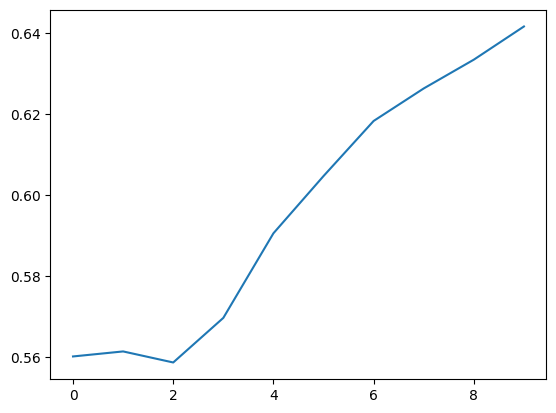

In [27]:
plt.plot(model_history.history["accuracy"])

In [28]:
def show_predictions(dataset=None, num=1):

    if dataset:
        for image, mask in dataset.take(num):
            pred_mask = unet.predict(image)
            display([image[0], mask[0], create_mask(pred_mask)])
    else:
        display([sample_image, sample_mask,
             create_mask(unet.predict(sample_image[tf.newaxis, ...]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


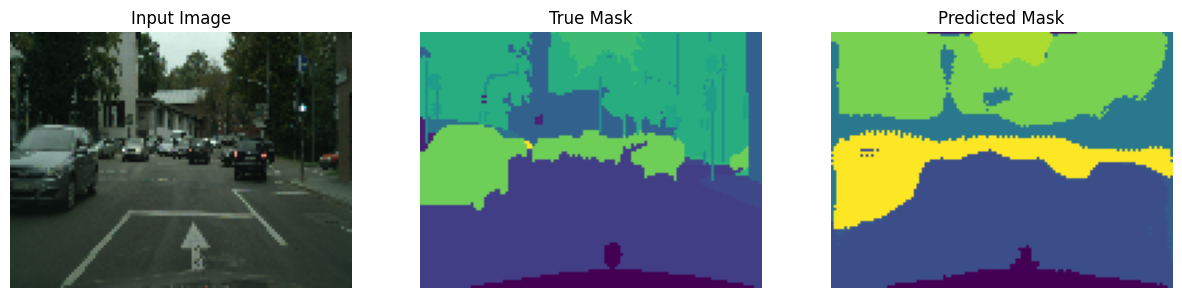

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


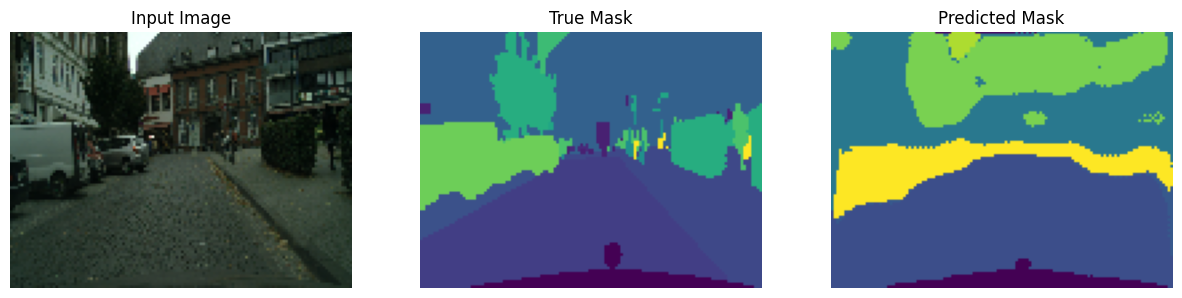

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


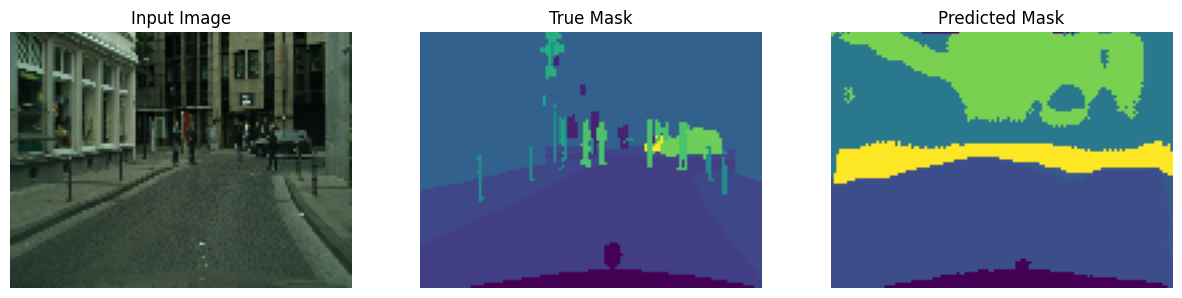

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


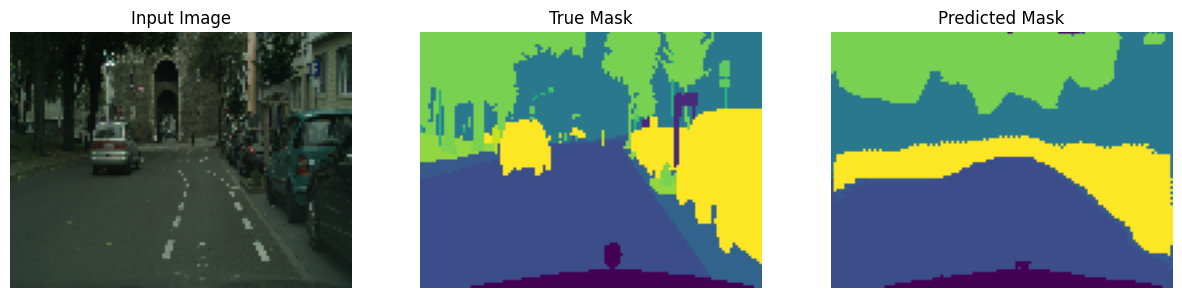

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


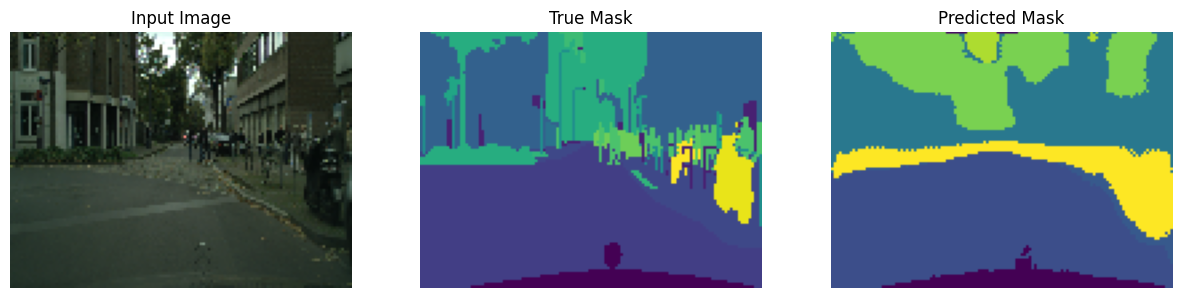

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


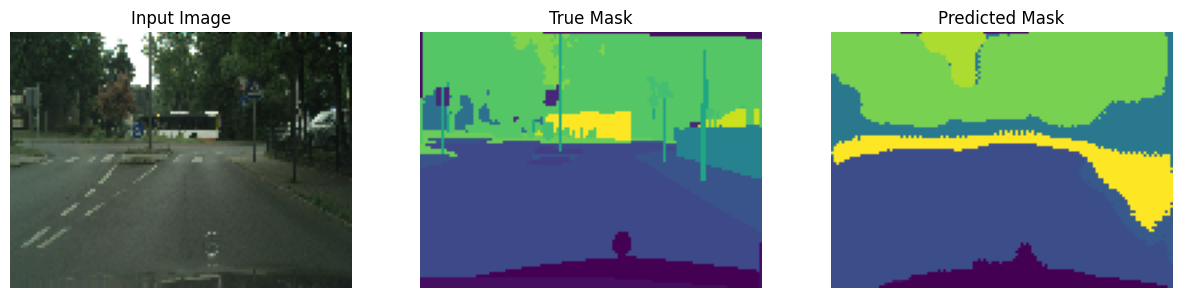

In [29]:
show_predictions(train_dataset, 6)